1. Carregando dados do arquivo CSV: 'dados_20000_para_ml.csv'...
-> Dados carregados com sucesso. Total de linhas: 21690
-> Total de eventos rotulados como Risco (Falha=1): 3934
2. Dimensionalidade reduzida para 3 Componentes Principais (PCA).

| 3. RESULTADO FINAL (Recall Médio K-Fold - RF): 0.9657 |
-> Modelos (Scaler, PCA, Random Forest) salvos com sucesso (PKL).


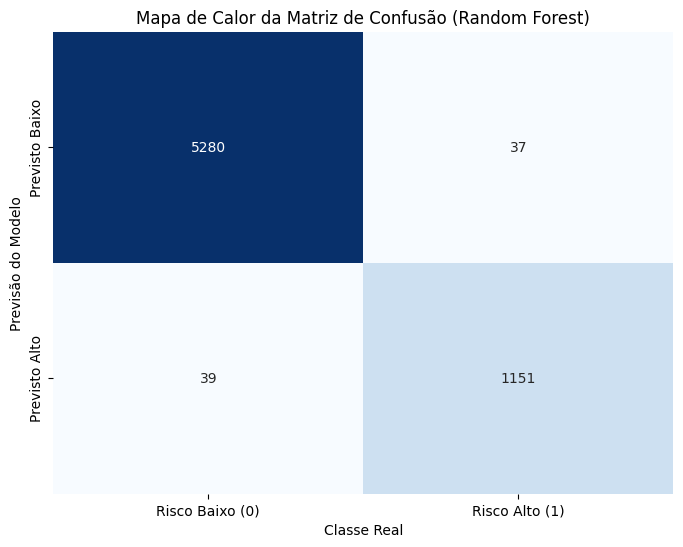

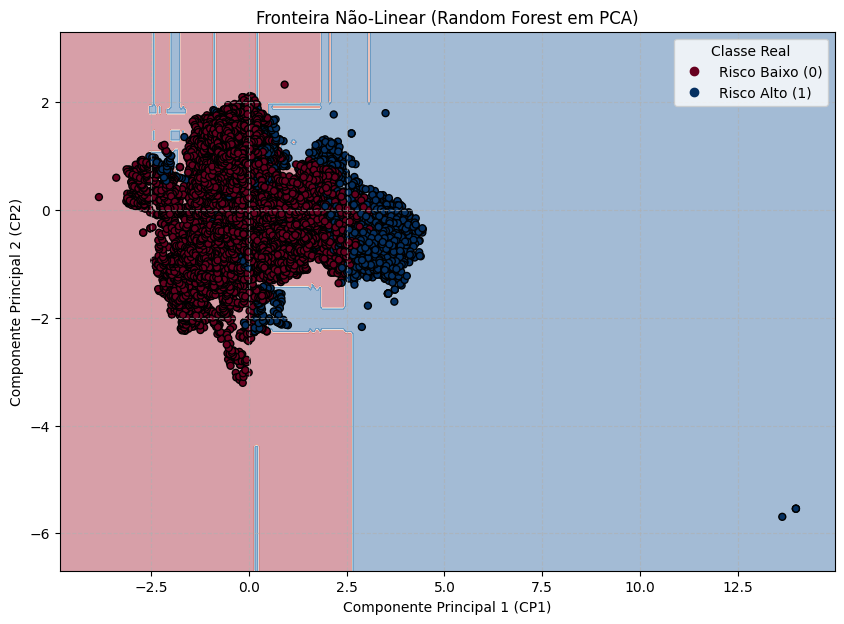

In [3]:
!pip install matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, accuracy_score
import joblib

FILE_PATH = 'dados_20000_para_ml.csv'

def select_and_prepare_data():
    """Carrega os dados de um CSV local (exportado do Supabase), cria o rótulo de falha e pré-processa as features."""
    print(f"1. Carregando dados do arquivo CSV: '{FILE_PATH}'...")
    try:
        # pega registros do CSV
        df = pd.read_csv(FILE_PATH)

        if df.empty:
            print("Erro: Arquivo CSV vazio ou não encontrado.")
            return None, None

        print(f"-> Dados carregados com sucesso. Total de linhas: {len(df)}")

        # criacao do rotulo de falha e limites
        TEMPERATURA_LIMITE = 88.0
        VIBRACAO_LIMITE = 5.0

        df['Falha'] = (
            (df['temperatura'] > TEMPERATURA_LIMITE) |
            (df['vibracao'] > VIBRACAO_LIMITE)
        ).astype(int)

        features = ['temperatura', 'vibracao', 'pressao_envelope', 'pressao_saco_ar', 'pecas_produzidas']

        X = df[features].fillna(df[features].mean())
        y = df['Falha']

        print(f"-> Total de eventos rotulados como Risco (Falha=1): {y.sum()}")

        return X, y

    except FileNotFoundError:
        print(f"Erro: Arquivo '{FILE_PATH}' não encontrado. Por favor, exporte os 20.000 registros do Supabase e suba o arquivo CSV para o Colab com este nome.")
        return None, None
    except Exception as e:
        print(f"Erro ao carregar ou processar o CSV: {e}")
        return None, None


def run_ml_pipeline(X, y):
    """Aplica PCA, Random Forest, K-Fold, calcula as métricas e retorna os objetos para plotagem."""

    # escalonamento e PCA
    scaler = StandardScaler()
    X_escalado = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_escalado)
    print(f"2. Dimensionalidade reduzida para {X_pca.shape[1]} Componentes Principais (PCA).")

    # modelagem e validacao (Random Forest + K-Fold)
    modelo_nao_linear = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    recall_scorer = make_scorer(recall_score, average='binary', zero_division=0)
    scores_recall = cross_val_score(modelo_nao_linear, X_pca, y, cv=kf, scoring=recall_scorer)
    recall_medio = np.mean(scores_recall)

    print("\n" + "="*50)
    print(f"| 3. RESULTADO FINAL (Recall Médio K-Fold - RF): {recall_medio:.4f} |")
    print("="*50)

    # matriz de confusao
    X_treino, X_teste, y_treino, y_teste = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    modelo_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    modelo_final.fit(X_treino, y_treino)
    y_predito = modelo_final.predict(X_teste)

    matriz = confusion_matrix(y_teste, y_predito)

    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(pca, 'pca.pkl')
    joblib.dump(modelo_final, 'modelo_rf_final.pkl')
    print("-> Modelos (Scaler, PCA, Random Forest) salvos com sucesso (PKL).")

    return X_pca, y, matriz, modelo_final


def plot_results(X_pca, y_labels, matriz, modelo_final):
    """Gera o mapa de calor da Matriz de Confusão e o gráfico de PCA/LDA."""

    # mapa de calor da matriz de confusao
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Risco Baixo (0)', 'Risco Alto (1)'],
                yticklabels=['Previsto Baixo', 'Previsto Alto'])
    plt.xlabel('Classe Real')
    plt.ylabel('Previsão do Modelo')
    plt.title('Mapa de Calor da Matriz de Confusão (Random Forest)')
    plt.show()

    # visualização da Fronteira de Decisão (PCA/LDA)
    modelo_plot = RandomForestClassifier(n_estimators=10, random_state=42)
    modelo_plot.fit(X_pca[:, :2], y_labels)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    Z = modelo_plot.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap=plt.cm.RdBu,
                          edgecolor='k', s=25)

    plt.xlabel('Componente Principal 1 (CP1)')
    plt.ylabel('Componente Principal 2 (CP2)')
    plt.title('Fronteira Não-Linear (Random Forest em PCA)')
    plt.legend(handles=scatter.legend_elements()[0],
               labels=['Risco Baixo (0)', 'Risco Alto (1)'],
               title="Classe Real")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


X_data, y_labels = select_and_prepare_data()

if X_data is not None:
    X_pca, y_labels_full, matriz_final, modelo_final = run_ml_pipeline(X_data, y_labels)
    plot_results(X_pca, y_labels_full, matriz_final, modelo_final)

In [4]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, accuracy_score

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_data)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_escalado)

modelo_final = LDA()
modelo_final.fit(X_pca, y_labels)

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(modelo_final, 'modelo_lda_final.pkl')

print("Modelos salvos (scaler.pkl, pca.pkl, modelo_lda_final.pkl).")

Modelos salvos (scaler.pkl, pca.pkl, modelo_lda_final.pkl). Baixe estes arquivos para o seu backend.
